IMPORTS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

IMPORTAR CSV

In [2]:
df = pd.read_csv("CCH_dataset.csv")

SELECCIONAR CT

In [3]:
ct_estudio = "CT-0710"

df_ct = df[df["ct"] == ct_estudio].copy()

PIVOTAR DATASET

In [4]:
df_ct["datalectura"] = pd.to_datetime(df_ct["datalectura"], errors="coerce")
df_ct["fecha"] = df_ct["datalectura"].dt.date

In [5]:
df_pivot = df_ct.pivot_table(
    index="fecha",
    columns="hora",
    values="ENERGIA_ENTRANTE"
)
print(df_pivot)

hora             0        1        2        3       4       5       6   \
fecha                                                                    
2025-06-01  152.572  141.910  114.766   98.791  84.885  80.565  80.544   
2025-06-02  149.046  144.015  131.118  118.668  88.563  91.227  86.485   
2025-06-03  150.101  141.056  115.092  104.445  79.465  88.367  85.613   
2025-06-04  153.073  128.106  108.074   84.331  91.091  86.583  80.915   
2025-06-05  183.973  149.081  107.709   90.564  82.893  79.793  78.291   
...             ...      ...      ...      ...     ...     ...     ...   
2026-05-27  133.834  119.859   95.934  100.152  88.241  75.162  81.884   
2026-05-28  149.099  118.977   95.972   80.654  77.469  70.355  78.035   
2026-05-29  147.454   98.382   91.081   85.751  81.481  78.711  79.730   
2026-05-30  142.729  103.693   96.773   78.557  84.206  90.935  87.652   
2026-05-31  142.026  121.789   92.396   81.599  79.770  78.316  75.049   

hora             7        8        9 

ESCALAR DATOS

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_pivot)

ELBOW METHOD 

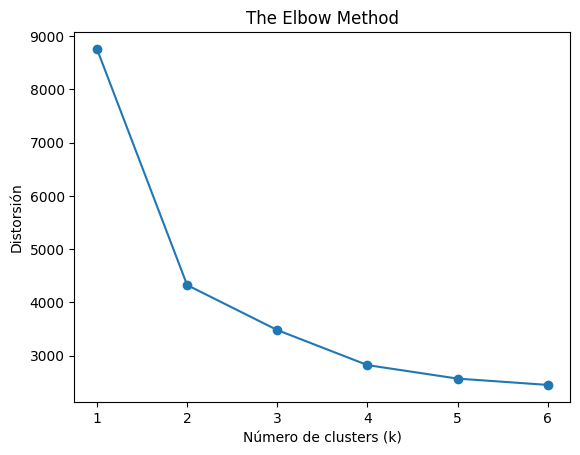

In [15]:
distortions = []

K = range(1,7)

for k in K:

    model = KMeans( n_clusters=k, random_state=42)

    model.fit(X_scaled)

    distortions.append(model.inertia_)

plt.plot(K, distortions, marker="o")

plt.title("The Elbow Method")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Distorsión")
plt.show()

Silhouette

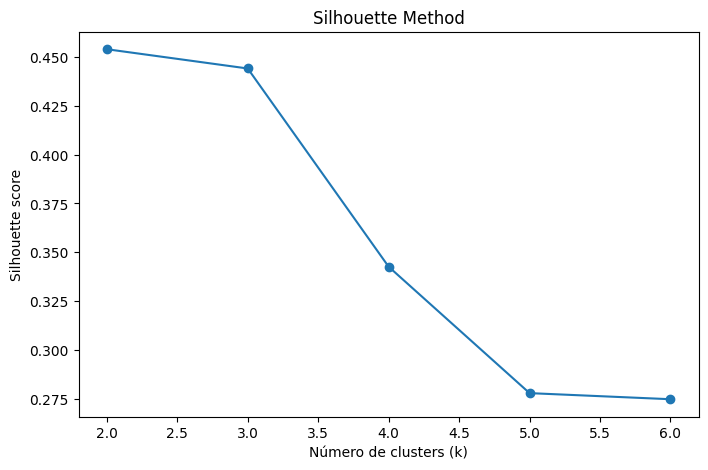

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

K = range(2, 7)  

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(K, silhouette_scores, marker="o")

plt.title("Silhouette Method")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")

plt.show()

ENTRENO K-MEANS

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df_pivot["cluster"] = clusters

VISUALIZACIÓN CLUSTERS

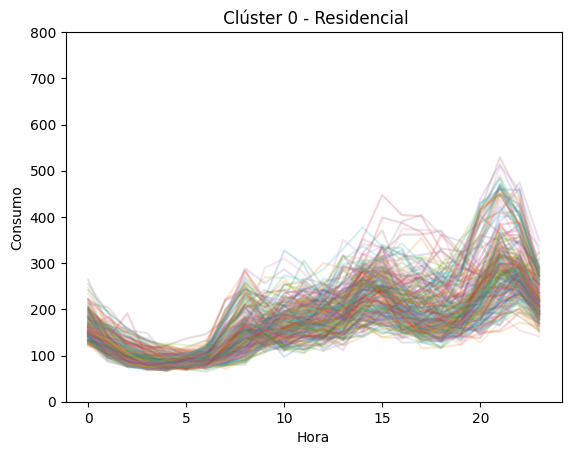

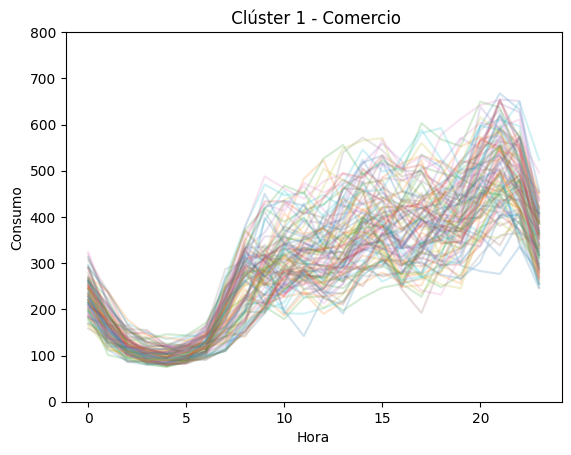

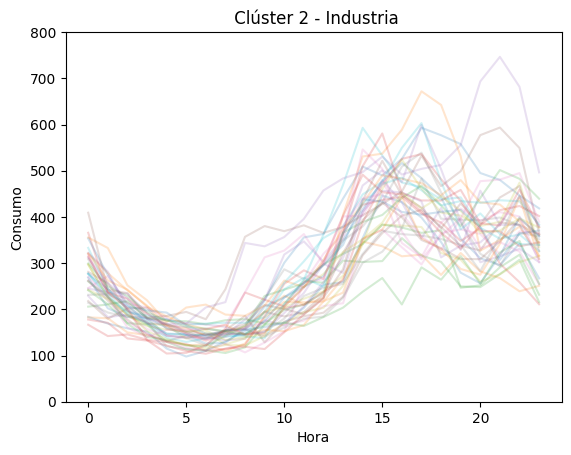

In [26]:
labels = {
    0: "Residencial",
    1: "Comercio",
    2: "Industria"
}
for cluster in sorted(df_pivot["cluster"].unique()):

    subset = df_pivot[df_pivot["cluster"] == cluster]

    ax = subset.drop("cluster", axis=1).T.plot(
        legend=False,
        alpha=0.2
    )

    ax.set_ylim(0, 800)

    ax.set_title(f" Clúster {cluster} - {labels.get(cluster, 'Desconocido')}")
    ax.set_xlabel("Hora")
    ax.set_ylabel("Consumo")

    plt.show()

ESTADÍSTICAS

In [10]:
#Valores consumo horario por clusters
df_pivot.groupby("cluster").mean()

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cluster,,,,,,,,,,,,,,,,,,,,,
0,161.890410,127.564458,103.396872,91.991969,86.504137,87.058445,93.100123,120.392863,155.365128,157.831035,...,229.173185,238.069855,213.111035,201.583273,197.994238,209.027242,245.613850,294.246374,290.088626,221.066837
1,233.132921,165.139149,121.438020,105.195505,99.061366,105.665881,123.721208,185.998446,256.401297,287.082832,...,382.122436,389.696554,366.488990,383.257050,391.540990,406.138238,467.738475,506.524455,473.056287,351.523752
2,274.157405,229.271351,196.732000,172.316568,153.078514,144.898919,141.659676,149.309027,165.368811,188.437622,...,406.615730,438.828297,434.769784,431.832676,404.370432,385.330784,368.635270,379.263216,396.302811,336.460784


In [11]:
#Número de días por cluster
df_pivot["cluster"].value_counts()

cluster
0    227
1    101
2     37
Name: count, dtype: int64

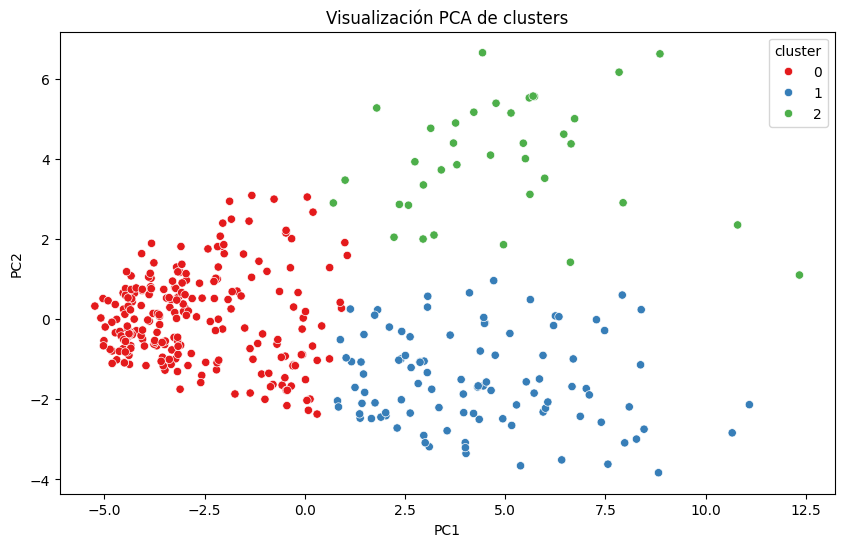

In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame()

df_pca["PC1"] = X_pca[:,0]
df_pca["PC2"] = X_pca[:,1]

df_pca["cluster"] = clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1"
)

plt.title("Visualización PCA de clusters")

plt.show()